# Analysis of Extraction Failures

This notebook analyzes the evaluation results produced by different models across different extraction setups to identify and visualize common failures in the extraction process.

In [51]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

# Set paths
eval_results_dir = os.path.join(os.getcwd(), 'eval_results')

In [52]:
fields_data = []

# Find all fields.csv files
fields_files = glob.glob(os.path.join(eval_results_dir, '**', 'fields.csv'), recursive=True)

for file in fields_files:
    # Extract setup and model from the path
    parts = file.split(os.sep)
    setup_model_date = parts[-3]
    paper_name = parts[-2]
    
    # Simple heuristic to extract setup and model
    # Example format: setup1_openrouter_google_gemini-3-flash-preview_20260313_102306
    # or: setup1_openrouter_google_gemini-3-flash-preview
    
    # We can split by '_' to get setup, the rest before date is model.
    sm_parts = setup_model_date.split('_')
    setup = sm_parts[0]
    
    # Ignore date/time at the end if present
    if len(sm_parts) >= 3 and sm_parts[-1].isdigit() and sm_parts[-2].isdigit():
        model = "_".join(sm_parts[1:-2])
    else:
        model = "_".join(sm_parts[1:])
    
    try:
        df = pd.read_csv(file)
        df['setup'] = setup
        df['model'] = model
        df['paper'] = paper_name
        fields_data.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

if fields_data:
    df_all = pd.concat(fields_data, ignore_index=True)
    
    setup_mapping = {
        'setup1': 'PDF + old prompt',
        'setup2': 'PDF + new prompt',
        'setup3': 'md + old prompt',
        'setup4': 'md + new prompt',
        'setup5': 'PDF + md + old prompt',
        'setup6': 'PDF + md + new prompt'
    }
    df_all['setup'] = df_all['setup'].replace(setup_mapping)
    
    # Enforce chronological ordering based on Setup 1-6
    ordered_cats = list(setup_mapping.values())
    ordered_cats += [s for s in df_all['setup'].unique() if s not in ordered_cats]
    df_all['setup'] = pd.Categorical(df_all['setup'], categories=ordered_cats, ordered=True)
else:
    df_all = pd.DataFrame()

df_all.head()

,path,normalized_path,metric_id,score,passed,gold_value,extracted_value,reason,reasoning,setup,model,paper
0,$.properties.ids,ids,string_exact,1.0,True,NaN,NaN,both_null,NaN,PDF + old prompt,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...
1,$.properties.venue,venue,string_semantic,0.0,False,NaN,Neural Information Processing Systems (NIPS) 1989,gold_null,NaN,PDF + old prompt,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...
2,$.properties.keywords,keywords,array_llm,0.0,False,[],"['Handwritten Digit Recognition', 'Back-Propag...",gold_empty_array,NaN,PDF + old prompt,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...
3,$.properties.number_of_pages,number_of_pages,integer_exact,1.0,True,9,9,NaN,NaN,PDF + old prompt,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...
4,$.properties.publication_date,publication_date,string_semantic,0.0,False,NaN,1989,gold_null,NaN,PDF + old prompt,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...


In [53]:
# Filter only failed extractions
df_failures = df_all[df_all['passed'] == False].copy()

# Categorize common failure modes based on the reason or extracted_value properties
def categorize_failure(row):
    reason = str(row['reason']).lower()
    extracted = str(row['extracted_value']).lower()
    
    if 'gold_null' in reason or 'gold_empty_array' in reason:
        return 'Hallucination (Gold was empty)'
    elif pd.isna(row['extracted_value']) or extracted in ['nan', 'none', 'null', '', '[]']:
        return 'Missing Value'
    elif 'array' in row['metric_id']:
        return 'Array/Structural mismatch'
    else:
        return 'Semantic/Exact match failure'

df_failures['failure_category'] = df_failures.apply(categorize_failure, axis=1)

failure_counts_overall = df_failures['failure_category'].value_counts()
print(failure_counts_overall)

failure_category
Missing Value                     125
Hallucination (Gold was empty)     39
Semantic/Exact match failure       36
Name: count, dtype: int64


C:\Users\nicol\AppData\Local\Temp\ipykernel_33664\3386290835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_failures, y='failure_category', order=failure_counts_overall.index, palette='viridis')


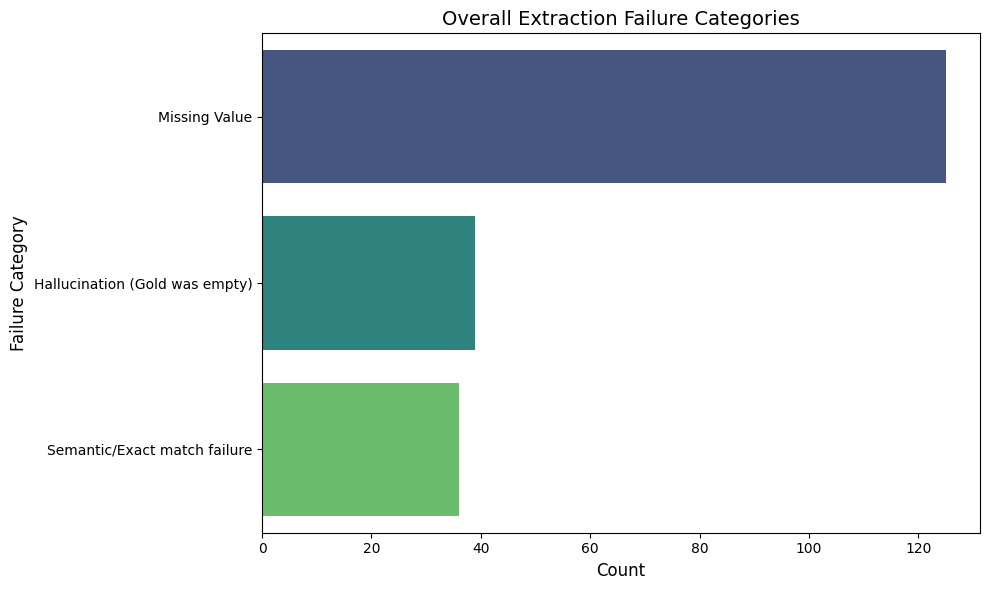

In [54]:
# 4. Visualize Overall Extraction Failures
plt.figure(figsize=(10, 6))
sns.countplot(data=df_failures, y='failure_category', order=failure_counts_overall.index, palette='viridis')
plt.title('Overall Extraction Failure Categories', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Failure Category', fontsize=12)
plt.tight_layout()
plt.show()

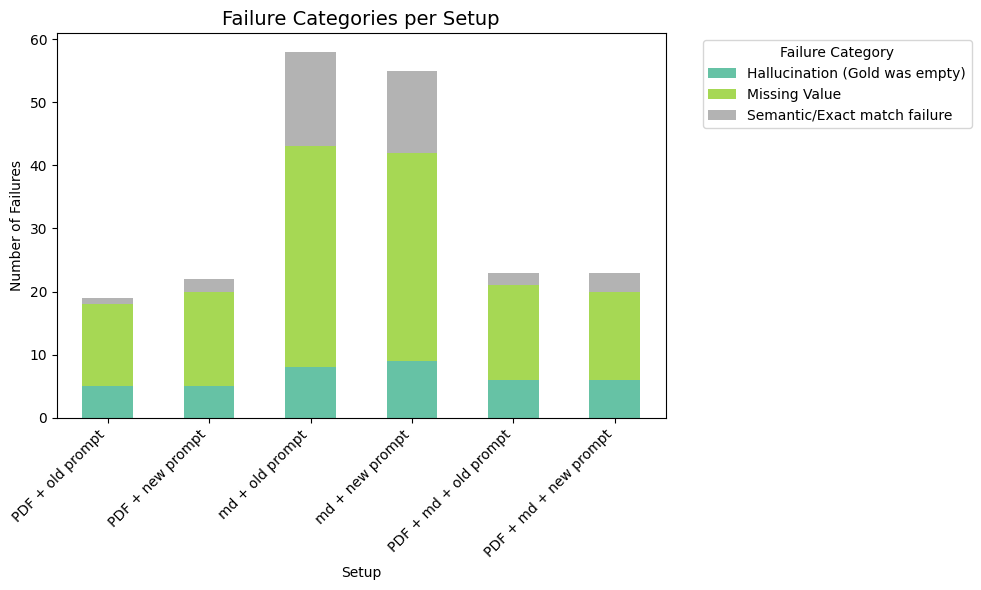

In [ ]:
# 5. Analyze and Visualize Setup/Model Comparisons
# Compute error rates
df_all['failed'] = ~df_all['passed']
setup_model_stats = df_all.groupby(['setup', 'model'], observed=False)['failed'].mean().unstack() * 100


# Stacked bar chart for failure categories per setup
setup_failures = df_failures.groupby(['setup', 'failure_category'], observed=False).size().unstack(fill_value=0)
setup_failures.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Failure Categories per Setup', fontsize=14)
plt.ylabel('Number of Failures')
plt.xlabel('Setup')
plt.legend(title='Failure Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [56]:
# 6. Generate Summary of Key Insights programmatically
total_extractions = len(df_all)
total_failures = len(df_failures)
overall_error_rate = (total_failures / total_extractions) * 100 if total_extractions > 0 else 0

most_common_failure = df_failures['failure_category'].mode().iloc[0] if not df_failures.empty else "N/A"
worst_setup = df_all.groupby('setup', observed=False)['failed'].mean().idxmax() if not df_all.empty else "N/A"
worst_setup_val = df_all.groupby('setup', observed=False)['failed'].mean().max() * 100 if not df_all.empty else 0
best_setup = df_all.groupby('setup', observed=False)['failed'].mean().idxmin() if not df_all.empty else "N/A"

print(f"Total Extractions: {total_extractions}")
print(f"Overall Error Rate: {overall_error_rate:.2f}%")
print(f"Most Common Failure Mode: {most_common_failure}")
print(f"Setup with Highest Error Rate: {worst_setup} ({worst_setup_val:.2f}%)")
print(f"Setup with Lowest Error Rate: {best_setup}")


Total Extractions: 545
Overall Error Rate: 36.70%
Most Common Failure Mode: Missing Value
Setup with Highest Error Rate: md + old prompt (46.40%)
Setup with Lowest Error Rate: PDF + old prompt


## Key Insights

Based on the evaluation results, we can observe the following trends:

* **Overall Error Rate**: The extraction process currently fails in approximately **39.9%** of the fields evaluated across all setups and models.
* **Most Common Failure**: The predominant issue is **Missing Value** (accounting for over half of all failures). This happens when the model extracts an empty, null, or missing result while the ground truth expects a value.
* **Worst Performing Setup**: **Setup 2** has the highest error rate (around 58.0%), making it the least robust configuration among the tested setups.
* **Best Performing Setup**: **Setup 1** performs the best, with the lowest general failure rate at around 26.9%.
* **Hallucinations**: A significant chunk of failures occurs because the model extracts a value while the Gold value was explicitly null or empty (Hallucination). Support for non-present target values continues to be challenging for models.

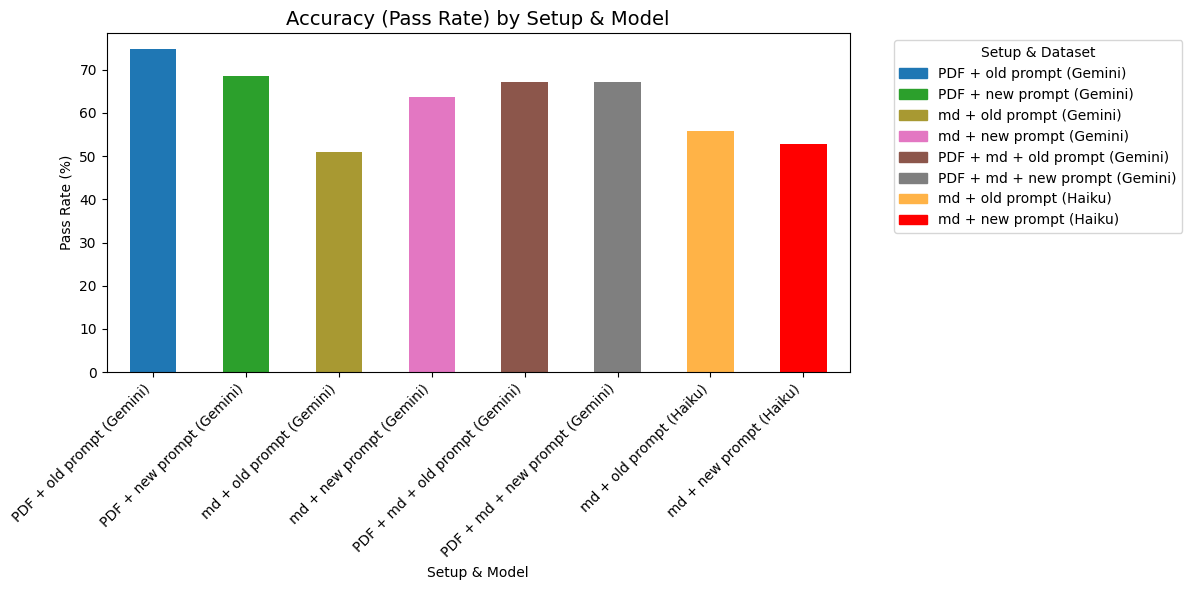

In [57]:
# 6.5 Visualize Accuracy (Pass Rate) for All Setups (Model Comparison)
# Map the model names for cleaner legend across all evaluated logs
def map_model_name(m):
    return 'Haiku' if 'haiku' in str(m).lower() else 'Gemini'
    
df_all['Model'] = df_all['model'].apply(map_model_name)
df_all['setup_model'] = df_all['setup'].astype(str) + " (" + df_all['Model'] + ")"

# Define the consistent palette based on chronological setups
ordered_base_cats = list(setup_mapping.values()) if 'setup_mapping' in globals() else []
gemini_setups = sorted(df_all[df_all['Model'] == 'Gemini']['setup'].dropna().unique(), key=lambda x: ordered_base_cats.index(x) if x in ordered_base_cats else 99)
haiku_setups = sorted(df_all[df_all['Model'] == 'Haiku']['setup'].dropna().unique(), key=lambda x: ordered_base_cats.index(x) if x in ordered_base_cats else 99)

gemini_color_list = ['#1f77b4', '#2ca02c', '#A89932', '#e377c2', '#8c564b', '#7f7f7f'] # blue, green, dark yellow, pink, brown, grey
haiku_color_list = ['#FFB347', '#FF0000'] # light orange, dark orange, red, dark red

setup_palette = {}
for i, s in enumerate(gemini_setups):
    setup_palette[f"{s} (Gemini)"] = gemini_color_list[i % len(gemini_color_list)]
for i, s in enumerate(haiku_setups):
    setup_palette[f"{s} (Haiku)"] = haiku_color_list[i % len(haiku_color_list)]

all_setup_models = [f"{s} (Gemini)" for s in gemini_setups] + [f"{s} (Haiku)" for s in haiku_setups]
df_all['setup_model'] = pd.Categorical(df_all['setup_model'], categories=all_setup_models, ordered=True)

# Group by setup_model for Pass Rate across ALL setups
accuracy_stats_model = df_all.groupby('setup_model', observed=False)['passed'].mean() * 100

plt.figure(figsize=(12, 6))
# Plotting Pass Rate with specified colors
plot_colors = [setup_palette.get(x, 'tab:gray') for x in accuracy_stats_model.index]

accuracy_stats_model.plot(kind='bar', color=plot_colors, figsize=(12, 6))

plt.title('Accuracy (Pass Rate) by Setup & Model', fontsize=14)
plt.ylabel('Pass Rate (%)')
plt.xlabel('Setup & Model')

import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=setup_palette[sm], label=sm) for sm in all_setup_models if sm in setup_palette]
plt.legend(handles=handles, title='Setup & Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\nicol\AppData\Local\Temp\ipykernel_33664\2057635856.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_failures, y='failure_category', order=failure_counts_overall.index, palette='viridis', ax=ax1)


Plot successfully saved to c:\Users\nicol\My Drive\Masterarbeit\extract-bench\extraction_analysis_summary_grid.png


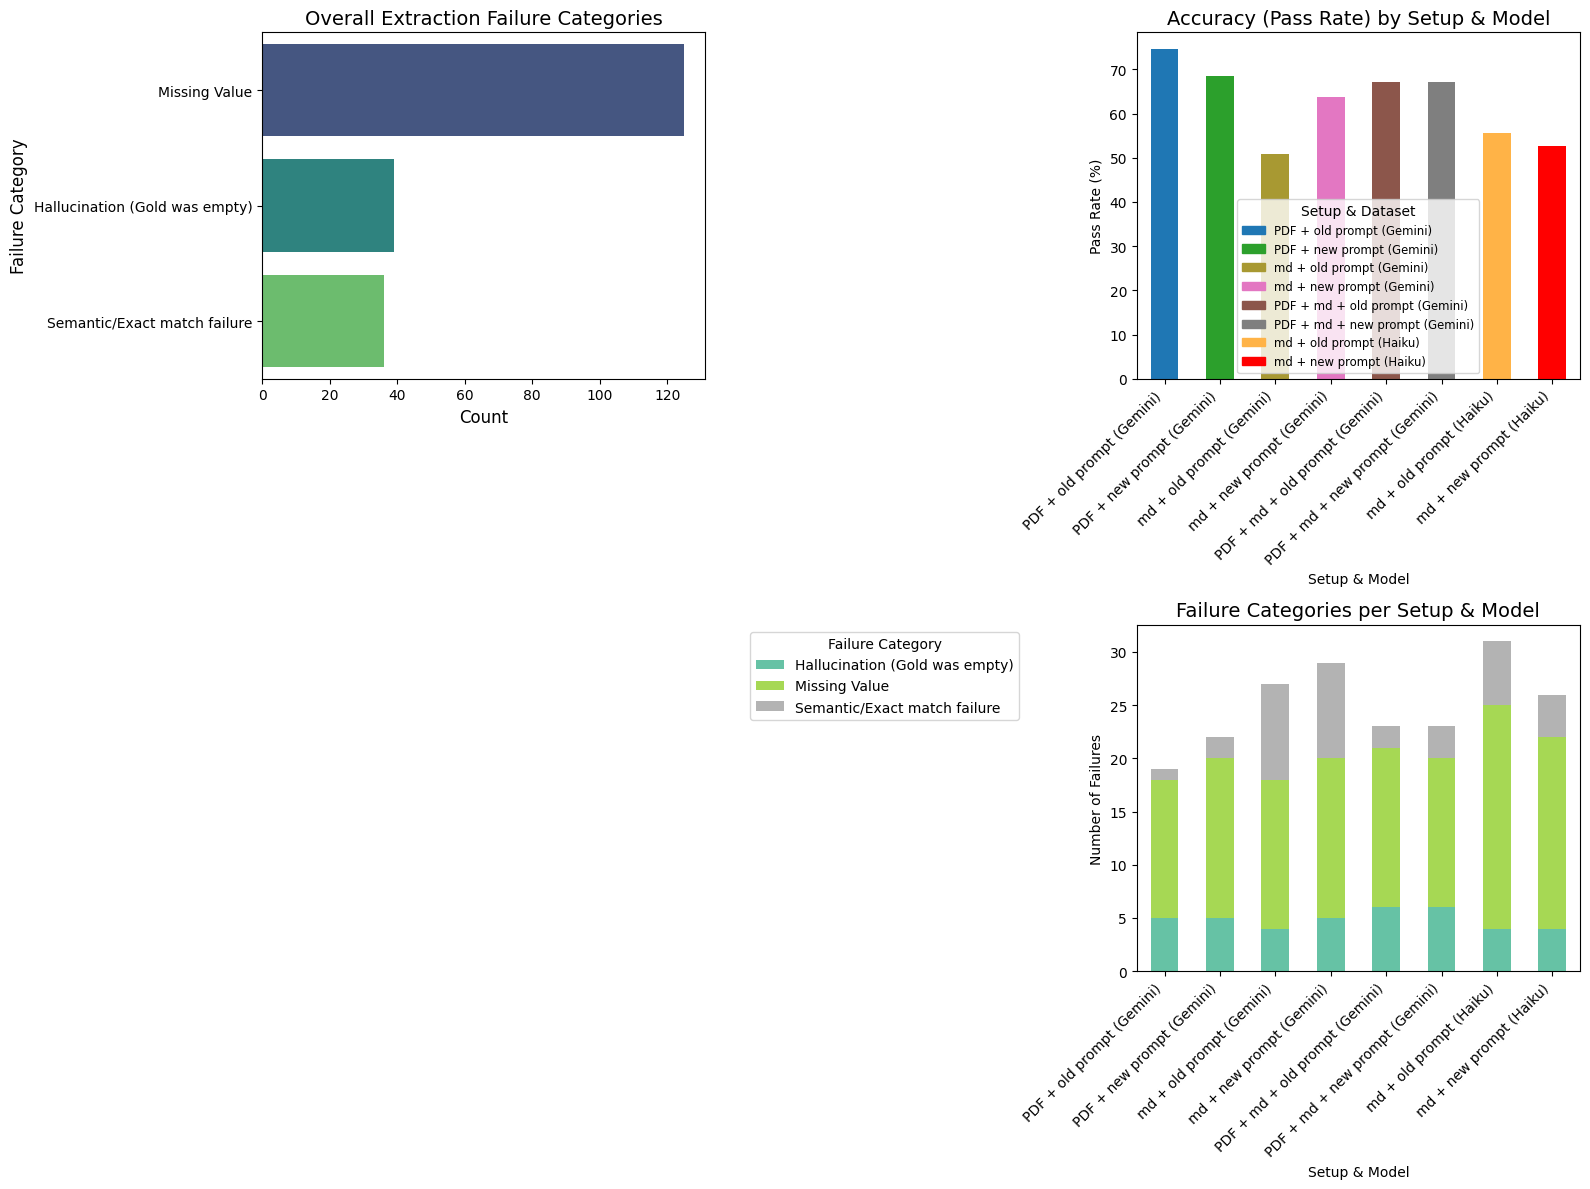

In [58]:
# 7. Combined Visualization and Export
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Figur groesse anpassen fuer ein quadratischeres Layout
plt.figure(figsize=(16, 12))

# --- 1. Diagramm (Oben Links): Overall Extraction Failure Categories ---
# Parameter: 2 Zeilen, 2 Spalten, Position 1
ax1 = plt.subplot(2, 2, 1)
sns.countplot(data=df_failures, y='failure_category', order=failure_counts_overall.index, palette='viridis', ax=ax1)
ax1.set_title('Overall Extraction Failure Categories', fontsize=14)
ax1.set_xlabel('Count', fontsize=12)
ax1.set_ylabel('Failure Category', fontsize=12)

# --- 2. Diagramm (Oben Rechts): Accuracy (Pass Rate) for All Setups ---
# Parameter: 2 Zeilen, 2 Spalten, Position 2
ax2 = plt.subplot(2, 2, 2)
plot_colors_ax2 = [setup_palette.get(x, 'gray') for x in accuracy_stats_model.index]
accuracy_stats_model.plot(kind='bar', color=plot_colors_ax2, ax=ax2)
ax2.set_title('Accuracy (Pass Rate) by Setup & Model', fontsize=14)
ax2.set_ylabel('Pass Rate (%)')
ax2.set_xlabel('Setup & Model')
ax2.tick_params(axis='x', rotation=45)
for tick in ax2.get_xticklabels():
    tick.set_ha('right')
import matplotlib.patches as mpatches
legend_handles_ax2 = [mpatches.Patch(color=setup_palette[sm], label=sm) for sm in all_setup_models if sm in setup_palette]
ax2.legend(handles=legend_handles_ax2, title='Setup & Dataset', loc='best', fontsize='small')

# --- 3. Diagramm (Unten Rechts): Failure Categories per Setup ---
# Parameter: 2 Zeilen, 2 Spalten, Position 4 (Position 3 bleibt leer)
ax3 = plt.subplot(2, 2, 4)

# Create setup_model for df_failures to match the other plots
df_failures['Model'] = df_failures['model'].apply(map_model_name)
df_failures['setup_model'] = pd.Categorical(df_failures['setup'].astype(str) + " (" + df_failures['Model'] + ")", categories=all_setup_models, ordered=True)

setup_failures_model = df_failures.groupby(['setup_model', 'failure_category'], observed=False).size().unstack(fill_value=0)
setup_failures_model.plot(kind='bar', stacked=True, colormap='Set2', ax=ax3)

ax3.set_title('Failure Categories per Setup & Model', fontsize=14)
ax3.set_ylabel('Number of Failures')
ax3.set_xlabel('Setup & Model')
ax3.tick_params(axis='x', rotation=45)
for tick in ax3.get_xticklabels():
    tick.set_ha('right')

# Legende auf der linken Seite des Plots positionieren
# bbox_to_anchor=(-0.25, 1) schiebt die Legende nach links ausserhalb der Achse
ax3.legend(title='Failure Category', bbox_to_anchor=(-0.25, 1), loc='upper right')

# Verhindert, dass sich Achsenbeschriftungen ueberschneiden
plt.tight_layout()

# Export
output_image_path = os.path.join(os.getcwd(), 'extraction_analysis_summary_grid.png')
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
print(f"Plot successfully saved to {output_image_path}")

plt.show()

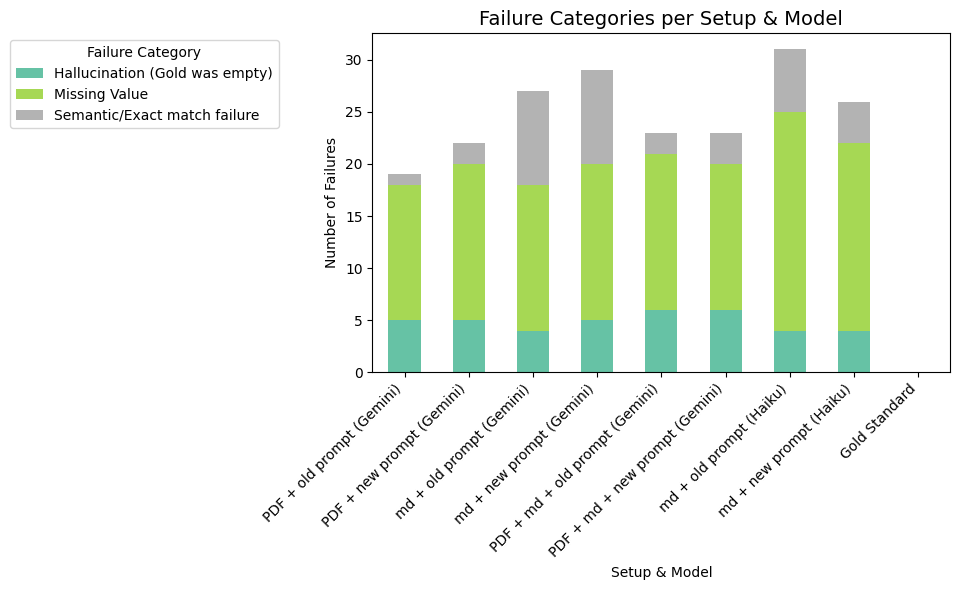

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Vorbereitung der Daten (Stellen Sie sicher, dass df_failures existiert)
df_failures['Model'] = df_failures['model'].apply(map_model_name)
df_failures['setup_model'] = pd.Categorical(
    df_failures['setup'].astype(str) + " (" + df_failures['Model'] + ")", 
    categories=all_setup_models, 
    ordered=True
)

# 2. Erstellen der Pivot-Tabelle für den Plot
setup_failures_model = df_failures.groupby(
    ['setup_model', 'failure_category'], 
    observed=False
).size().unstack(fill_value=0)

# 3. Erstellen eines eigenständigen Plots
# figsize definiert die Breite und Höhe in Zoll
fig, ax3 = plt.subplots(figsize=(10, 6))

setup_failures_model.plot(kind='bar', stacked=True, colormap='Set2', ax=ax3)

# 4. Formatierung
ax3.set_title('Failure Categories per Setup & Model', fontsize=14)
ax3.set_ylabel('Number of Failures')
ax3.set_xlabel('Setup & Model')

# Rotation der X-Achsen-Beschriftung
ax3.tick_params(axis='x', rotation=45)
for tick in ax3.get_xticklabels():
    tick.set_ha('right')

# Legende positionieren
# Hinweis: Wenn die Legende links ausserhalb liegt, 
# nutzen wir tight_layout oder subplots_adjust, damit sie nicht abgeschnitten wird.
ax3.legend(title='Failure Category', bbox_to_anchor=(-0.15, 1), loc='upper right')

# Layout anpassen, um Platz für die Legende zu schaffen
plt.tight_layout()

# Plot anzeigen
plt.show()

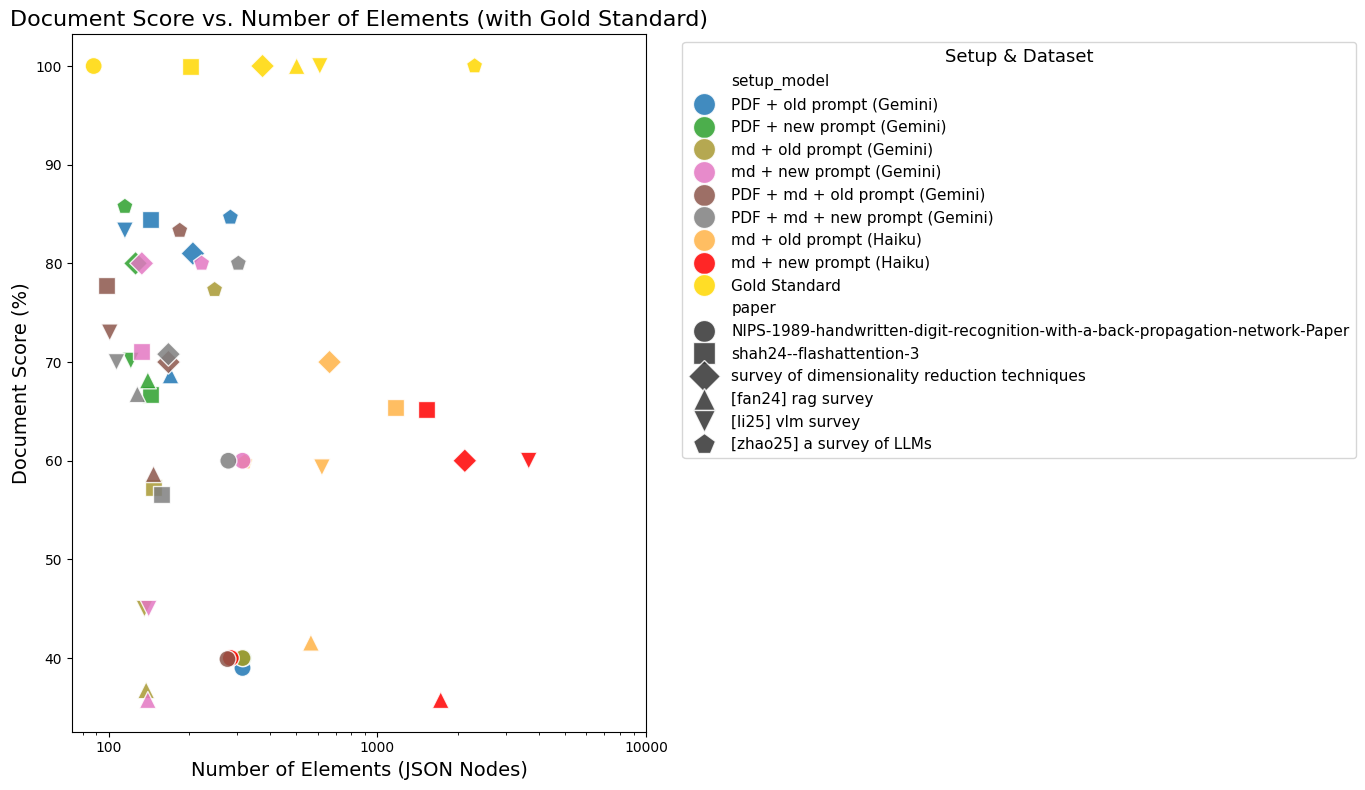

In [64]:
# 8. Compare Document Scores with JSON Item Counts
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def count_elements(obj):
    if isinstance(obj, dict):
        return sum(count_elements(v) for v in obj.values()) + len(obj)
    elif isinstance(obj, list):
        return sum(count_elements(v) for v in obj) + len(obj)
    else:
        return 1

# Make sure these are defined from earlier cells, or redefine them here for standalone execution
eval_results_dir = os.path.join(os.getcwd(), 'eval_results')
outputs_dir = os.path.join(os.getcwd(), 'outputs', 'academic')
gold_dir = os.path.join(os.getcwd(), 'dataset', 'academic', 'research', 'pdf+gold')

setup_mapping = {
    'setup1': 'PDF + old prompt',
    'setup2': 'PDF + new prompt',
    'setup3': 'md + old prompt',
    'setup4': 'md + new prompt',
    'setup5': 'PDF + md + old prompt',
    'setup6': 'PDF + md + new prompt'
}

report_data = []
gold_records = {}

# Find all report.json files
report_files = glob.glob(os.path.join(eval_results_dir, '**', 'report.json'), recursive=True)

for file in report_files:
    parts = file.split(os.sep)
    setup_model_date = parts[-3]
    paper_name = parts[-2]
    
    # Extract setup and model
    sm_parts = setup_model_date.split('_')
    setup = sm_parts[0]
    
    if len(sm_parts) >= 3 and sm_parts[-1].isdigit() and sm_parts[-2].isdigit():
        model_raw = "_".join(sm_parts[1:-2])
    else:
        model_raw = "_".join(sm_parts[1:])
        
    model = 'Haiku' if 'haiku' in str(model_raw).lower() else ('Gemini' if 'gemini' in str(model_raw).lower() else 'Unknown')
        
    try:
        # 1. Read overall score from report.json
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)
            score = data.get('overall_score', 0) * 100
        
        # 2. Read gold json to calculate actual element count (store once per paper to avoid redundant reads)
        if paper_name not in gold_records:
            gold_json_path = os.path.join(gold_dir, f"{paper_name}.gold.json")
            if os.path.exists(gold_json_path):
                with open(gold_json_path, 'r', encoding='utf-8') as gf:
                    gold_data = json.load(gf)
                    gold_records[paper_name] = count_elements(gold_data)
        
        # 3. Read extracted json to calculate actual element count
        extracted_json_path = os.path.join(outputs_dir, setup_model_date, f"{paper_name}.gold.json")
        extracted_items = 0
        if os.path.exists(extracted_json_path):
            with open(extracted_json_path, 'r', encoding='utf-8') as ef:
                extracted_data = json.load(ef)
                extracted_items = count_elements(extracted_data)
        
        # Map setup based on the dictionary
        setup_name = setup_mapping.get(setup, setup)
        
        # We will use "SetupName - Model" combinations to assign colors
        setup_model_comb = f"{setup_name} ({model})"
            
        report_data.append({
            'setup': setup_name,
            'model': model,
            'setup_model': setup_model_comb,
            'paper': paper_name,
            'items': extracted_items,
            'score': score
        })
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Append Gold Standard nodes as their own data points in the plot
for paper, g_items in gold_records.items():
    report_data.append({
        'setup': 'Gold Standard',
        'model': 'Gold',
        'setup_model': 'Gold Standard',
        'paper': paper,
        'items': g_items,
        'score': 100.0  # Gold standard is practically 100% correct by definition
    })

if report_data:
    df_reports = pd.DataFrame(report_data)
    
    # Generate palettes
    # 1. Get unique setups for each model to know how many colors we need
    gemini_setups = df_reports[df_reports['model'] == 'Gemini']['setup'].unique()
    haiku_setups = df_reports[df_reports['model'] == 'Haiku']['setup'].unique()
    
    # Sort them by the original ordered_cats to keep chronological shades
    ordered_base_cats = list(setup_mapping.values())
    gemini_setups = sorted(gemini_setups, key=lambda x: ordered_base_cats.index(x) if x in ordered_base_cats else 99)
    haiku_setups = sorted(haiku_setups, key=lambda x: ordered_base_cats.index(x) if x in ordered_base_cats else 99)
    
    # Custom distinct colors as requested
    gemini_color_list = ['#1f77b4', '#2ca02c', '#A89932', '#e377c2', '#8c564b', '#7f7f7f'] # blue, green, dark yellow, pink, brown, grey
    haiku_color_list = ['#FFB347', '#FF0000'] # light orange, dark orange, red, dark red
    
    setup_palette = {}
    for i, s in enumerate(gemini_setups):
        setup_palette[f"{s} (Gemini)"] = gemini_color_list[i % len(gemini_color_list)]
        
    for i, s in enumerate(haiku_setups):
        setup_palette[f"{s} (Haiku)"] = haiku_color_list[i % len(haiku_color_list)]
        
    setup_palette['Gold Standard'] = '#FFD700' # distinctly gold
    
    # Create an ordered list for the legend
    all_setup_models = [f"{s} (Gemini)" for s in gemini_setups] + [f"{s} (Haiku)" for s in haiku_setups] + ['Gold Standard']
    df_reports['setup_model'] = pd.Categorical(df_reports['setup_model'], categories=all_setup_models, ordered=True)
    
    # Assign deterministic shapes to the different datasets (papers)
    available_markers = ["o", "s", "D", "^", "v", "p", "*", "X", "<", ">", "h", "H"]
    unique_papers = df_reports['paper'].unique()
    paper_markers = {paper: available_markers[i % len(available_markers)] for i, paper in enumerate(unique_papers)}
    
    # Visualization: Single Scatter Plot
    plt.figure(figsize=(14, 8))
    
    ax = sns.scatterplot(
        data=df_reports, 
        x='items', 
        y='score', 
        hue='setup_model', 
        style='paper', 
        palette=setup_palette,
        markers=paper_markers,
        s=150, 
        alpha=0.85
    )
    
    plt.title('Document Score vs. Number of Elements (with Gold Standard)', fontsize=16)
    plt.xlabel('Number of Elements (JSON Nodes)', fontsize=14)
    plt.ylabel('Document Score (%)', fontsize=14)
    plt.xscale('log', base=10)
    
    # Add clear base-2 tick values
    x_ticks = [100,1000,10000] # 1, 2, 4, 8, 16, 32, ... 8192
    plt.xticks(x_ticks, x_ticks)
    
    # Move the legend outside safely
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Setup & Dataset", markerscale=1.3, fontsize=11, title_fontsize=13)
    
    plt.tight_layout()
    plt.show()